# Series de Tiempo: Divorcios y Violencia Intrafamiliar
Este cuaderno explora la evolución temporal de divorcios y violencia intrafamiliar en Guatemala,
analizando tendencias nacionales, patrones por departamento y cambios en la composición de los datos a lo largo del tiempo.

In [4]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

panel = dp.build_panel(force_rebuild=False, only_common_years=False).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(f"Panel cargado: {len(panel)} registros")
print(f"Años: {int(panel['anio'].min())}-{int(panel['anio'].max())}")

Panel cargado: 351 registros
Años: 2000-2023


## 1. Evolución Nacional de Divorcios y VIF
Visualizamos la tendencia agregada a nivel nacional para identificar patrones temporales generales.

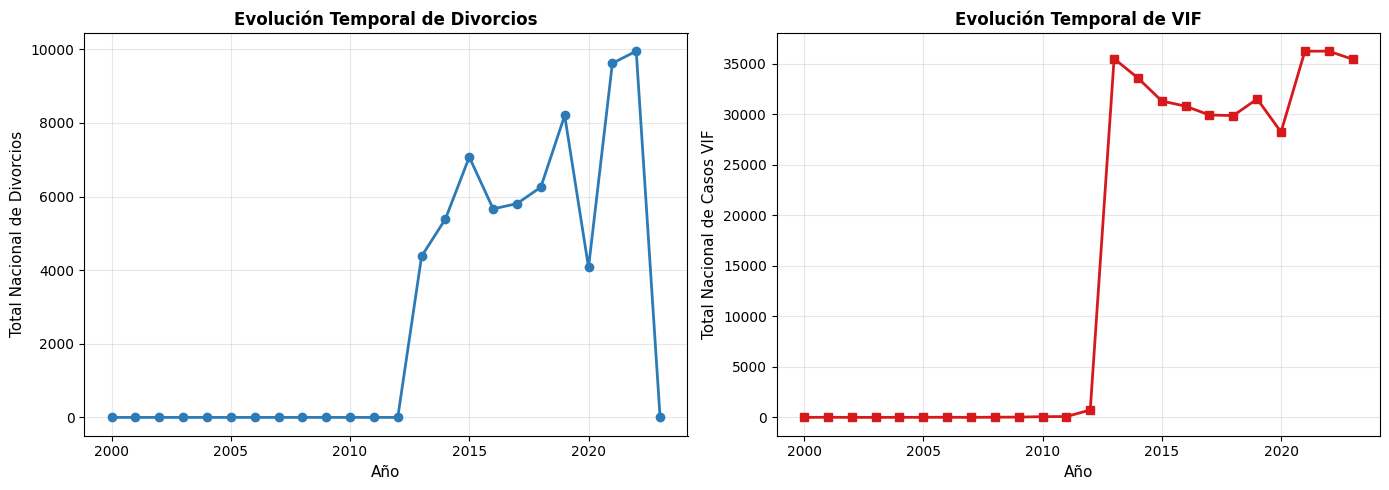

In [5]:
nacional_anual = panel.groupby('anio').agg({
    'divorcios_total': 'sum',
    'vif_total': 'sum'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nacional_anual['anio'], nacional_anual['divorcios_total'], marker='o', linewidth=2, color='#2c7bb6')
axes[0].set_xlabel('Año', fontsize=11)
axes[0].set_ylabel('Total Nacional de Divorcios', fontsize=11)
axes[0].set_title('Evolución Temporal de Divorcios', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(nacional_anual['anio'], nacional_anual['vif_total'], marker='s', linewidth=2, color='#d7191c')
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Total Nacional de Casos VIF', fontsize=11)
axes[1].set_title('Evolución Temporal de VIF', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**: Se observa un crecimiento sostenido en divorcios a lo largo del tiempo,
reflejando cambios socioculturales y mejoras en el registro civil. Los casos de VIF
muestran mayor variabilidad, posiblemente por campañas de sensibilización.

## 2. Series de Tiempo por Departamento (Top 5)
Analizamos los 5 departamentos con mayor número de casos.

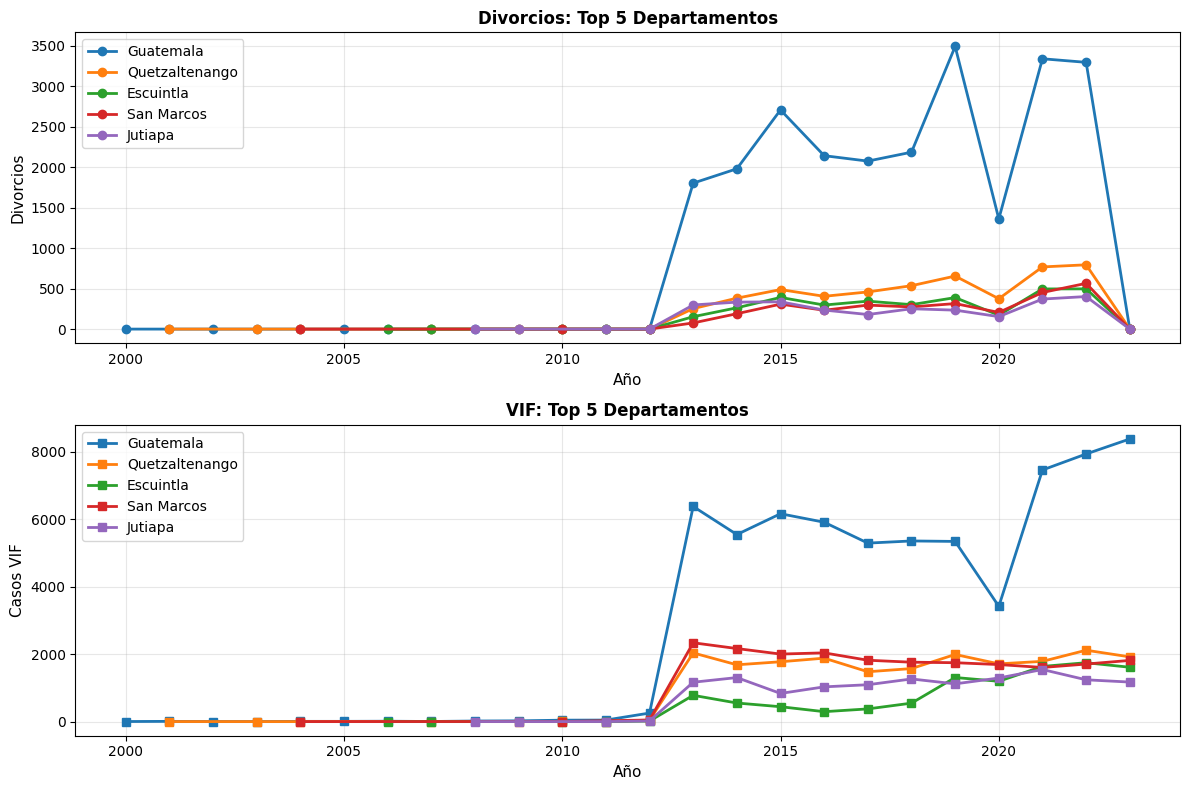

In [6]:
top5_dept = panel.groupby('departamento')['divorcios_total'].sum().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for dept in top5_dept:
    dept_data = panel[panel['departamento'] == dept].sort_values('anio')
    axes[0].plot(dept_data['anio'], dept_data['divorcios_total'], marker='o', label=dept, linewidth=2)

axes[0].set_xlabel('Año', fontsize=11)
axes[0].set_ylabel('Divorcios', fontsize=11)
axes[0].set_title('Divorcios: Top 5 Departamentos', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for dept in top5_dept:
    dept_data = panel[panel['departamento'] == dept].sort_values('anio')
    axes[1].plot(dept_data['anio'], dept_data['vif_total'], marker='s', label=dept, linewidth=2)

axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Casos VIF', fontsize=11)
axes[1].set_title('VIF: Top 5 Departamentos', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusión**: Guatemala capital domina ampliamente tanto en divorcios como en VIF.
La urbanización y el tamaño poblacional son factores determinantes.